### 📊 AED para explorar o Desempenho Acadêmico (IDA)

**Base:** `df_base_2.parquet` — consolidação gerada no Notebook `01_AED_DF_PROCESSED.ipynb`.

**❓Pergunta chave:**
- O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

**Sub-perguntas:**
- Qual o IDA médio por nível e por ano?
- Existe um nível "gargalo" onde o desempenho cai?
- Como as notas por disciplina (mat, por, ing) se relacionam com o IDA?
- Alunos defasados (IAN < 10) têm IDA menor?

#### ⚙️ Import e Setup

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar base consolidada
df = pd.read_parquet('../../data/db/01_silver_processed/df_base_2.parquet')

# Confirmar se bate com os resultados obtidos durante a etapa de preparação no notebook 01_AED_DF_PROCESSED.ipynb
print(f'df_base: {df.shape[0]} linhas | {df.shape[1]} colunas')
print(f'Anos: {sorted(df["ano"].unique())}')
print(f'Registros por ano: {df["ano"].value_counts().sort_index().to_dict()}')

df_base: 3030 linhas | 31 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Registros por ano: {2022: 860, 2023: 1014, 2024: 1156}


### 📊 Geração de plots e insights

#### Distribuição geral do IDA por ano

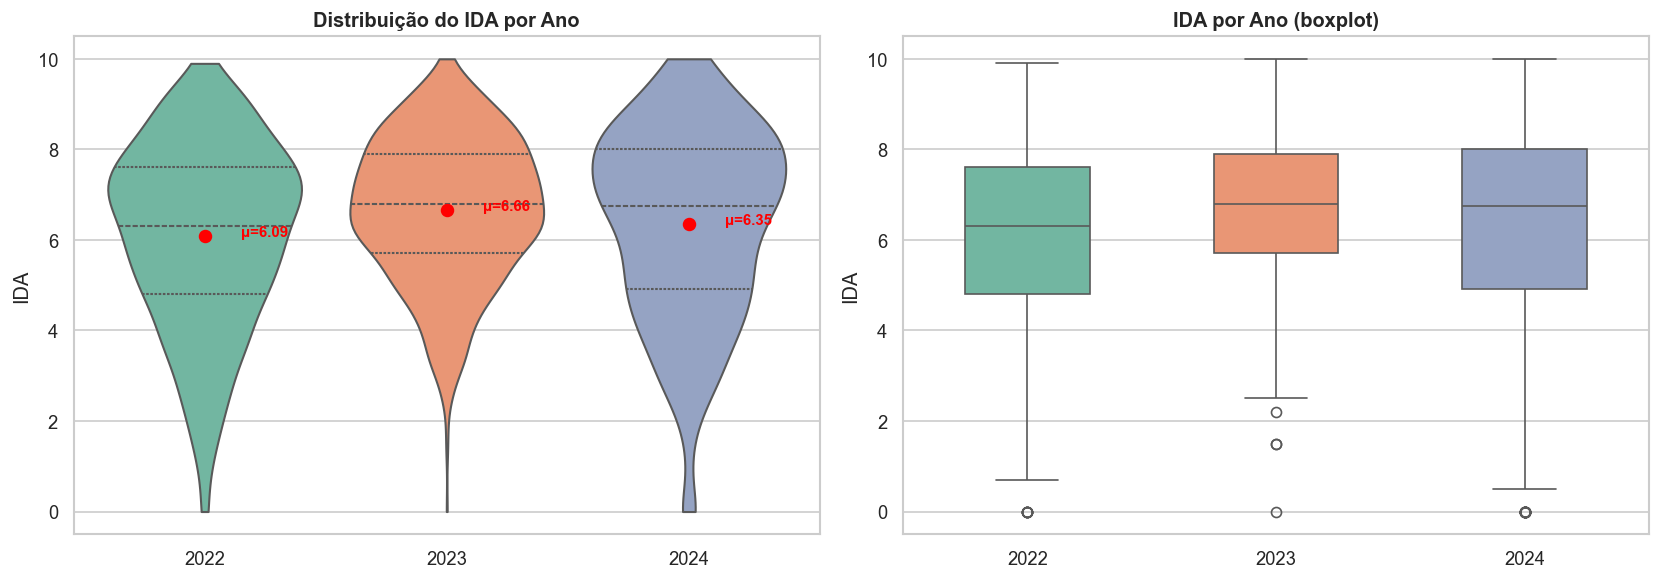

=== IDA — Estatísticas por ano ===
       count  mean   std  min   25%   50%  75%   max
ano                                                 
2022   860.0  6.09  2.05  0.0  4.80  6.30  7.6   9.9
2023   937.0  6.66  1.60  0.0  5.70  6.80  7.9  10.0
2024  1055.0  6.35  2.13  0.0  4.92  6.75  8.0  10.0


In [28]:
# Distribuição geral do IDA por ano
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violinplot — mostra a distribuição de forma mais clara que histograma
dados_violin = df[df['IDA'].notna()].copy()
dados_violin['ano'] = dados_violin['ano'].astype(str)

sns.violinplot(data=dados_violin, x='ano', y='IDA', ax=axes[0],
               palette='Set2', inner='quartile', cut=0)

# Adicionar média como ponto
medias = dados_violin.groupby('ano')['IDA'].mean()
for i, (ano, media) in enumerate(medias.items()):
    axes[0].scatter(i, media, color='red', s=50, zorder=5)
    axes[0].text(i + 0.15, media, f'μ={media:.2f}', fontsize=9, fontweight='bold', color='red')

axes[0].set_title('Distribuição do IDA por Ano', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IDA')

# Boxplot por ano
sns.boxplot(data=dados_violin, x='ano', y='IDA', ax=axes[1],
            palette='Set2', width=0.5)
axes[1].set_title('IDA por Ano (boxplot)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IDA')

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print('=== IDA — Estatísticas por ano ===')
print(df.groupby('ano')['IDA'].describe().round(2).to_string())

##### 💡 **Insights**

- O IDA não está melhorando de forma consistente - subiu em 2023, mas recuou em 2024
- A média de 2024 (6.35) caiu, mas a mediana (6.75) se manteve próxima de 2023 (6.80)
  - Isso pode indicar que a queda da média é puxada por alunos novos entrando com notas mais baixas, não por queda generalizada... vamos ver se isso se confirma
  - 2024 tem 1.156 alunos vs 1.014 em 2023 — o programa cresceu e trouxe alunos novos que ainda não atingiram o patamar dos veteranos
- O desvio padrão subiu (1.60 → 2.13) — a turma de 2024 é mais heterogênea

#### IDA - Ingressantes vs Veteranos

=== IDA médio: Ingressantes vs Veteranos ===
ano          2022  2023  2024
tipo_aluno                   
Ingressante  6.09  6.76  6.45
Veterano      NaN  6.60  6.30

=== Contagem ===
ano          2022  2023  2024
tipo_aluno                   
Ingressante   860   363   358
Veterano        0   574   697


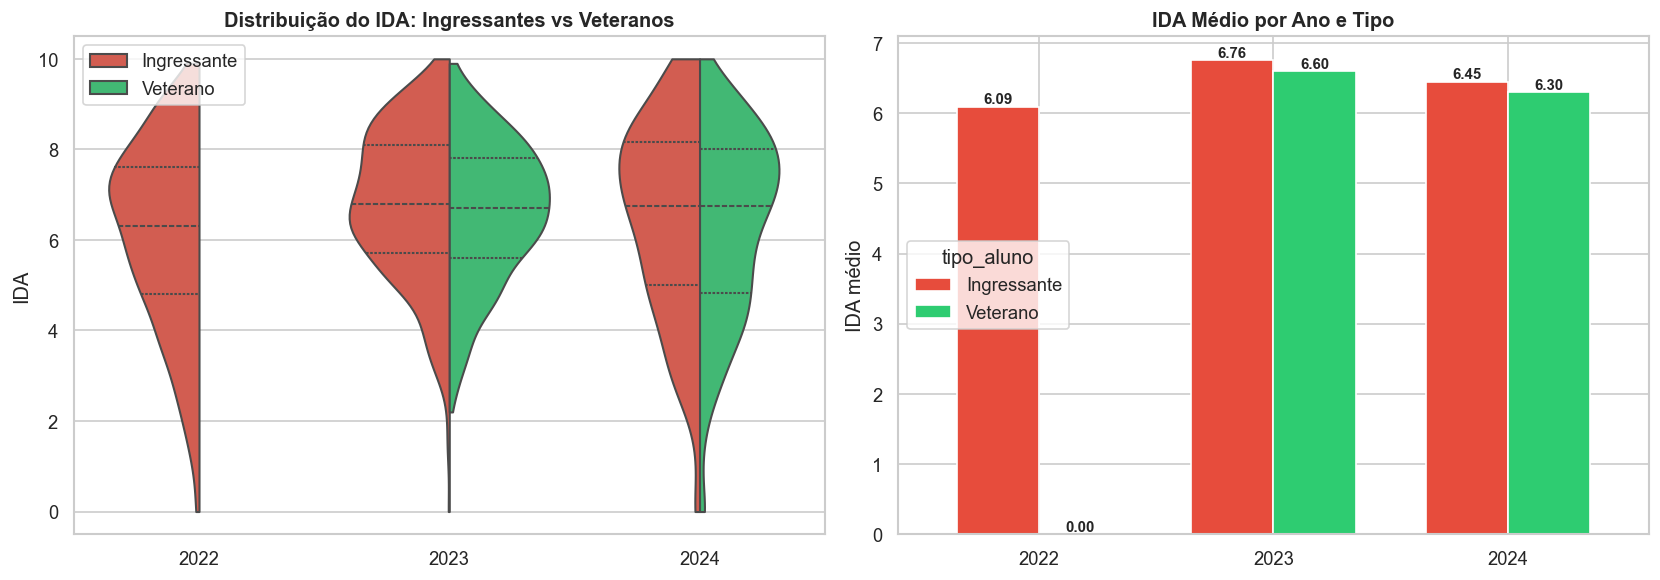


=== Diferença (Veterano - Ingressante) ===
  2022: Veteranos +nan pontos acima
  2023: Veteranos -0.16 pontos acima
  2024: Veteranos -0.15 pontos acima


In [29]:
# Identificar ingressantes (primeiro ano no dataset) vs veteranos
primeiro_ano = df.groupby('RA')['ano'].min().rename('primeiro_ano')
df_ida_vet = df[df['IDA'].notna()].merge(primeiro_ano, on='RA')
df_ida_vet['tipo_aluno'] = np.where(
    df_ida_vet['ano'] == df_ida_vet['primeiro_ano'], 'Ingressante', 'Veterano'
)

# IDA médio por tipo e ano
resumo = df_ida_vet.pivot_table(
    index='tipo_aluno', columns='ano', values='IDA', aggfunc=['mean', 'count']
)

print('=== IDA médio: Ingressantes vs Veteranos ===')
print(resumo['mean'].round(2).to_string())
print('\n=== Contagem ===')
print(resumo['count'].fillna(0).astype(int).to_string())

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violinplot separado por tipo
sns.violinplot(data=df_ida_vet, x='ano', y='IDA', hue='tipo_aluno',
               split=True, ax=axes[0], palette={'Ingressante': '#e74c3c', 'Veterano': '#2ecc71'},
               inner='quartile', cut=0)
axes[0].set_title('Distribuição do IDA: Ingressantes vs Veteranos', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('IDA')
axes[0].legend(title='')

# Barras com média
medias = df_ida_vet.pivot_table(index='ano', columns='tipo_aluno', values='IDA', aggfunc='mean')
medias.plot(kind='bar', ax=axes[1], color={'Ingressante': '#e74c3c', 'Veterano': '#2ecc71'},
            rot=0, width=0.7)
axes[1].set_title('IDA Médio por Ano e Tipo', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('IDA médio')

# Rótulos nas barras
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Diferença
print('\n=== Diferença (Veterano - Ingressante) ===')
diff = medias['Veterano'] - medias['Ingressante']
for ano, d in diff.items():
    print(f'  {ano}: Veteranos {d:+.2f} pontos acima')

##### 💡 Insights — IDA Veteranos vs Ingressantes

- A hipótese de que ingressantes puxam a média para baixo **não se confirma**
  - Ingressantes têm IDA levemente superior (+0.15)
- A queda de 2023 -> 2024 é **generalizada**: afeta tanto veteranos quanto ingressantes
  - Possíveis explicações: avaliação mais rigorosa em 2024, ou variação natural entre coortes
  - A diferença entre veteranos e ingressantes é pequena - **tipo de aluno não parece ser um fator forte para o IDA**

#### IDA médio por nível e ano

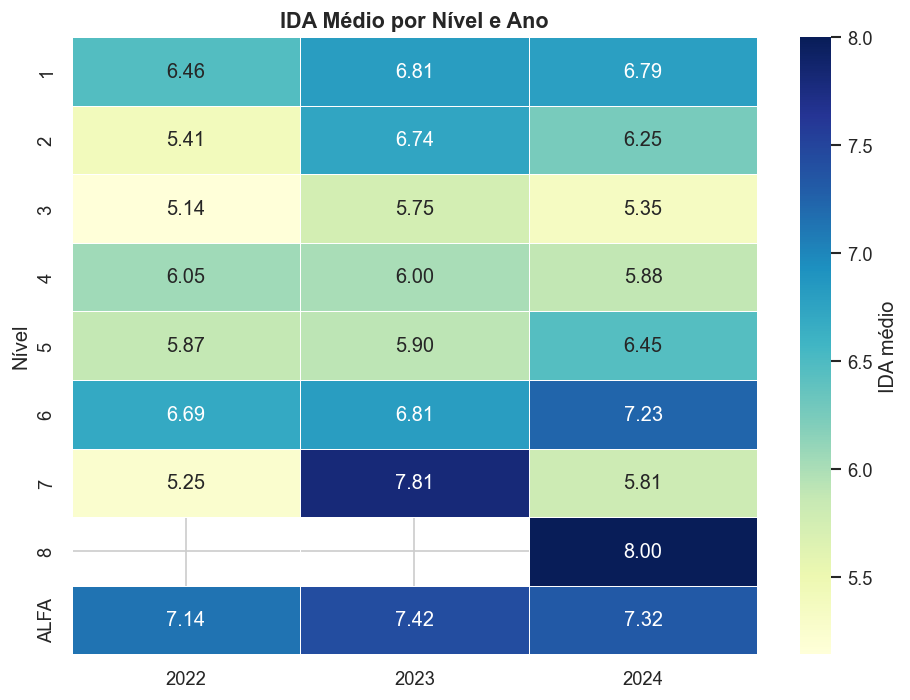

=== IDA médio por nível e ano ===
ano    2022  2023  2024
nivel                  
1      6.46  6.81  6.79
2      5.41  6.74  6.25
3      5.14  5.75  5.35
4      6.05  6.00  5.88
5      5.87  5.90  6.45
6      6.69  6.81  7.23
7      5.25  7.81  5.81
8       NaN   NaN  8.00
ALFA   7.14  7.42  7.32


In [30]:
# IDA médio por nível e ano
df_ida = df[df['IDA'].notna()].copy()

pivot_ida = df_ida.pivot_table(
    index='nivel', columns='ano', values='IDA', aggfunc='mean'
).astype(float).sort_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_ida, annot=True, fmt='.2f', cmap='YlGnBu',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'IDA médio'}
)
ax.set_title('IDA Médio por Nível e Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Nível')
plt.tight_layout()
plt.show()

print('=== IDA médio por nível e ano ===')
print(pivot_ida.round(2).to_string())

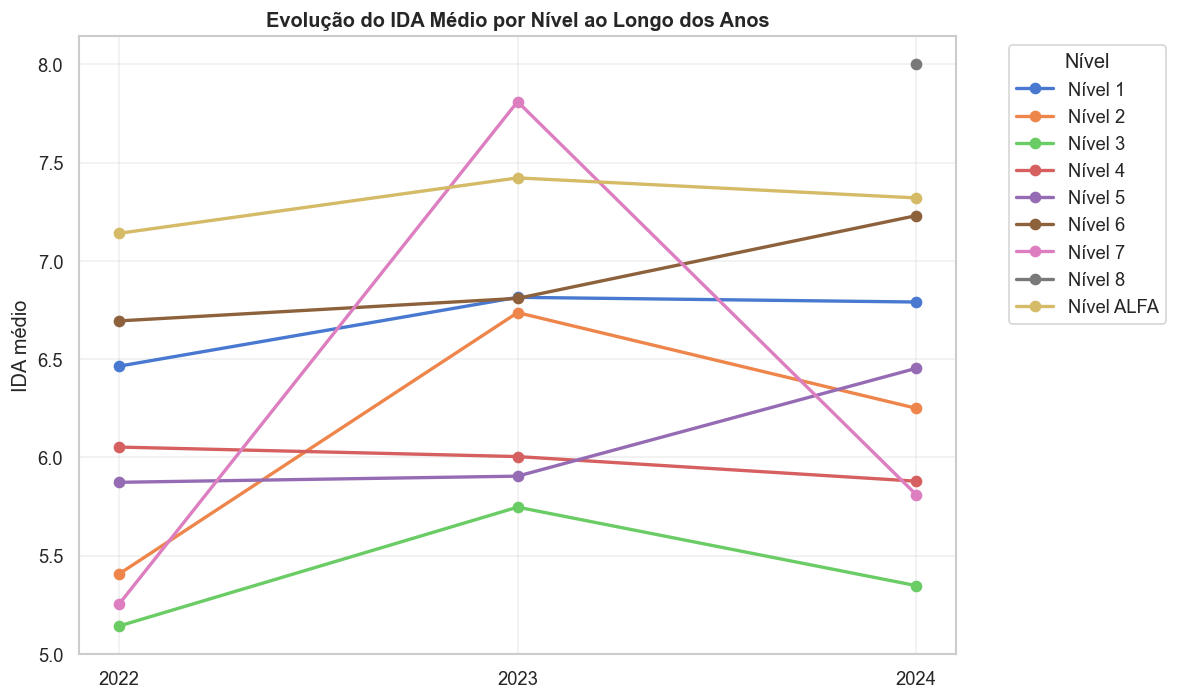

In [31]:
# Evolução do IDA por nível ao longo dos anos (linhas)
fig, ax = plt.subplots(figsize=(10, 6))

for nivel in pivot_ida.index:
    valores = pivot_ida.loc[nivel]
    ax.plot(valores.index.astype(str), valores.values,
            marker='o', linewidth=2, label=f'Nível {nivel}')

ax.set_title('Evolução do IDA Médio por Nível ao Longo dos Anos', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('IDA médio')
ax.legend(title='Nível', bbox_to_anchor=(1.05, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 💡 Insights 

- Nível 3 mostra os piores resultados nos 3 anos
- Níveis 5 e 6 apresentam melhoras
- Nível 7 teve uma queda muito grande entre 2023 e 2024
  - Qual será a razão da queda?
  - Ou melhor, por que teve um aumento tão expressivo em 2023, já que 2022 e 2024 o IDA ficou abaixo de 6

=== Nível 7 — Contagem por ano ===
ano
2022    21
2023    23
2024    37

=== IDA — Estatísticas por ano ===
      count  mean   std  min   25%   50%   75%   max
ano                                                 
2022   21.0  5.25  2.18  1.5  3.80  5.00  7.30  9.00
2023   10.0  7.81  0.68  6.8  7.55  7.80  7.98  9.00
2024   37.0  5.81  3.06  0.0  5.48  7.07  7.67  9.17

=== Sobreposição de alunos ===
  2022: 21 alunos
  2023: 23 alunos
  2024: 37 alunos
  Em 2022 E 2023: 1
  Em 2023 E 2024: 11
  Nos 3 anos:     0


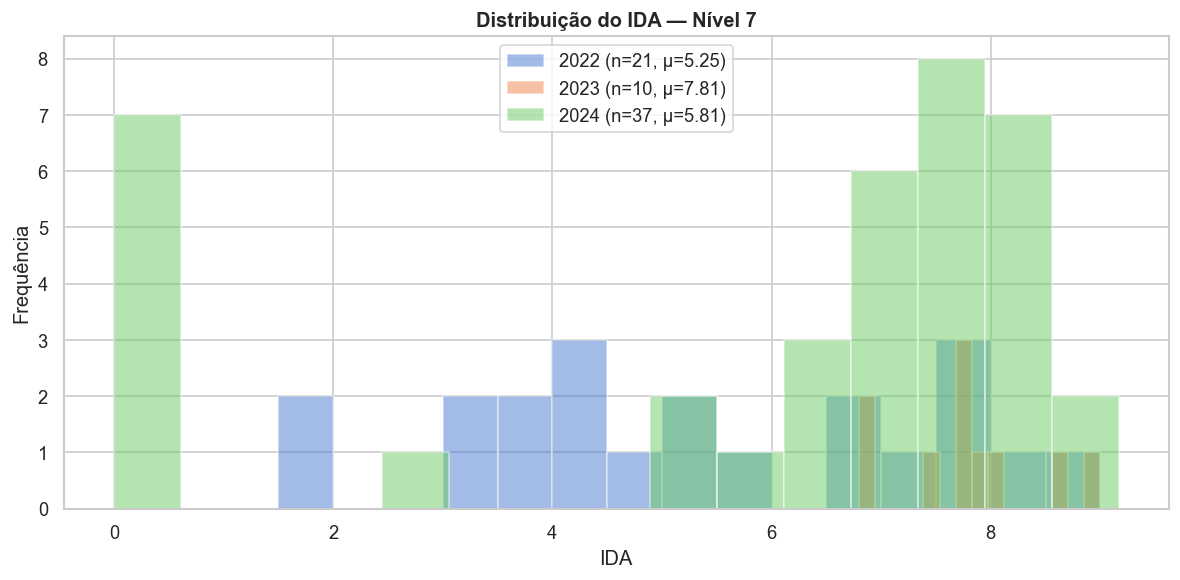

In [32]:
# Investigar o nível 7: por que IDA tão alto em 2023?
df_n7 = df[df['nivel'] == '7'].copy()

print('=== Nível 7 — Contagem por ano ===')
print(df_n7['ano'].value_counts().sort_index().to_string())

print('\n=== IDA — Estatísticas por ano ===')
print(df_n7.groupby('ano')['IDA'].describe().round(2).to_string())

# Verificar se são os mesmos alunos ou alunos diferentes
ras_por_ano = {ano: set(df_n7[df_n7['ano'] == ano]['RA']) for ano in [2022, 2023, 2024]}

print(f'\n=== Sobreposição de alunos ===')
print(f'  2022: {len(ras_por_ano[2022])} alunos')
print(f'  2023: {len(ras_por_ano[2023])} alunos')
print(f'  2024: {len(ras_por_ano[2024])} alunos')
print(f'  Em 2022 E 2023: {len(ras_por_ano[2022] & ras_por_ano[2023])}')
print(f'  Em 2023 E 2024: {len(ras_por_ano[2023] & ras_por_ano[2024])}')
print(f'  Nos 3 anos:     {len(ras_por_ano[2022] & ras_por_ano[2023] & ras_por_ano[2024])}')

# Ver distribuição do IDA no nível 7 por ano
fig, ax = plt.subplots(figsize=(10, 5))
for ano in [2022, 2023, 2024]:
    dados = df_n7[df_n7['ano'] == ano]['IDA'].dropna()
    if len(dados) > 0:
        ax.hist(dados, bins=15, alpha=0.5, label=f'{ano} (n={len(dados)}, μ={dados.mean():.2f})')

ax.set_title('Distribuição do IDA — Nível 7', fontweight='bold')
ax.set_xlabel('IDA')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
# Onde estão os 13 alunos do nível 7 em 2023 sem IDA?
df_n7_2023 = df[(df['nivel'] == '7') & (df['ano'] == 2023)].copy()

print(f'Total nível 7 em 2023: {len(df_n7_2023)}')
print(f'Com IDA: {df_n7_2023["IDA"].notna().sum()}')
print(f'Sem IDA: {df_n7_2023["IDA"].isna().sum()}')

# Ver os indicadores dos que não têm IDA
sem_ida = df_n7_2023[df_n7_2023['IDA'].isna()]
indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

print(f'\n=== Alunos sem IDA — outros indicadores ===')
print(sem_ida[['RA', 'nome', 'nivel', 'fase_ideal'] + indicadores].to_string())

# Comparar: os sem IDA também estão sem outros indicadores?
print(f'\n=== Nulos nos sem IDA ===')
print(sem_ida[indicadores].isnull().sum().to_string())

print(f'\n=== Nulos nos com IDA ===')
com_ida = df_n7_2023[df_n7_2023['IDA'].notna()]
print(com_ida[indicadores].isnull().sum().to_string())

Total nível 7 em 2023: 23
Com IDA: 10
Sem IDA: 13

=== Alunos sem IDA — outros indicadores ===
           RA        nome nivel               fase_ideal   IAN  IDA  IEG   IAA   IPS  IPP  IPV  INDE
1798  RA-1225  Aluno-1225     7  Fase 8 (Universitários)   5.0  NaN  NaN   7.5  2.52  NaN  NaN   NaN
1799    RA-76    Aluno-76     7           Fase 5 (1° EM)  10.0  NaN  NaN  10.0  2.52  NaN  NaN   NaN
1800    RA-26    Aluno-26     7  Fase 8 (Universitários)   5.0  NaN  NaN   0.0  7.52  NaN  NaN   NaN
1801  RA-1226  Aluno-1226     7           Fase 6 (2° EM)  10.0  NaN  NaN   9.2  7.52  NaN  NaN   NaN
1802    RA-93    Aluno-93     7           Fase 6 (2° EM)  10.0  NaN  NaN   7.9  3.14  NaN  NaN   NaN
1803   RA-119   Aluno-119     7           Fase 5 (1° EM)  10.0  NaN  NaN   6.7  2.52  NaN  NaN   NaN
1804  RA-1227  Aluno-1227     7           Fase 6 (2° EM)  10.0  NaN  NaN   9.2  2.52  NaN  NaN   NaN
1805  RA-1228  Aluno-1228     7           Fase 7 (3° EM)  10.0  NaN  NaN   7.5  2.52  NaN  NaN   

##### 💡 Insights 

- 13 alunos não possuem IDA (eles não possuem notas nas matérias), e também não possuem IEG, IPP, IPV e INDE
  - Será que eles não completaram o ciclo?
  - Será que eles estão em 2024?

In [34]:
# Verificar os 13 alunos sem IDA no nível 7 em 2023 — como estão em 2024?
ras_sem_ida = sem_ida['RA'].tolist()

df_2024_check = df[(df['RA'].isin(ras_sem_ida)) & (df['ano'] == 2024)].copy()

indicadores = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']

print(f'Dos 13 sem IDA em 2023, quantos aparecem em 2024: {len(df_2024_check)}')
print(f'Quantos NÃO aparecem em 2024: {len(ras_sem_ida) - len(df_2024_check)}')

if len(df_2024_check) > 0:
    print(f'\n=== Situação em 2024 ===')
    print(df_2024_check[['RA', 'nome', 'nivel', 'fase_ideal', 'pedra'] + indicadores].to_string())
    
    print(f'\n=== Nulos por indicador em 2024 ===')
    print(df_2024_check[indicadores].isnull().sum().to_string())
    
    print(f'\n=== IDA em 2024 (dos que têm) ===')
    ida_2024 = df_2024_check['IDA'].dropna()
    if len(ida_2024) > 0:
        print(f'  Com IDA: {len(ida_2024)} | Média: {ida_2024.mean():.2f}')
    else:
        print(f'  Nenhum tem IDA em 2024')

Dos 13 sem IDA em 2023, quantos aparecem em 2024: 13
Quantos NÃO aparecem em 2024: 0

=== Situação em 2024 ===
           RA        nome nivel               fase_ideal     pedra   IAN       IDA       IEG     IAA     IPS  IPP  IPV      INDE
2903  RA-1230  Aluno-1230     7           Fase 7 (3° EM)   Quartzo  10.0  0.000000  0.000000   7.917  7.1950  7.5  7.5  4.761200
2907    RA-76    Aluno-76     7           Fase 5 (1° EM)   Topázio  10.0  7.066667  9.000000  10.002  6.8850  7.5  7.5  8.152033
2909  RA-1226  Aluno-1226     7           Fase 7 (3° EM)  Ametista  10.0  6.066667  9.000000   8.334  6.8850  7.5  7.5  7.785233
2910    RA-93    Aluno-93     7           Fase 6 (2° EM)   Topázio  10.0  7.483333  9.931667   9.168  6.2575  7.5  7.5  8.275550
2911   RA-119   Aluno-119     7           Fase 6 (2° EM)   Topázio  10.0  7.366667  9.983333   7.083  6.5700  7.5  7.5  8.085300
2915  RA-1227  Aluno-1227     7           Fase 7 (3° EM)   Quartzo  10.0  0.000000  0.000000   8.751  7.1950  7.5  

##### 💡 Insights 

- OS 13 alunos que não possuem IDA em 2023 existem em 2024, logo ninguém saiu do programa!
  - 6 deles estão no grupo 1 e mostram um IDA entre 5.5 e 8.9
  - 4 estão com IDA e IEG zerados, o que puxa a média para baixo
    - Possuem IAA, IPS, IPP e IPV
    - Pelo visto, não estão participando
  - 2 são universitários

- Os 13 possuem um IDA médio de **4.48** (puxado para baixo devido aos 4 zeros). Sem eles, a média seria **6.9**

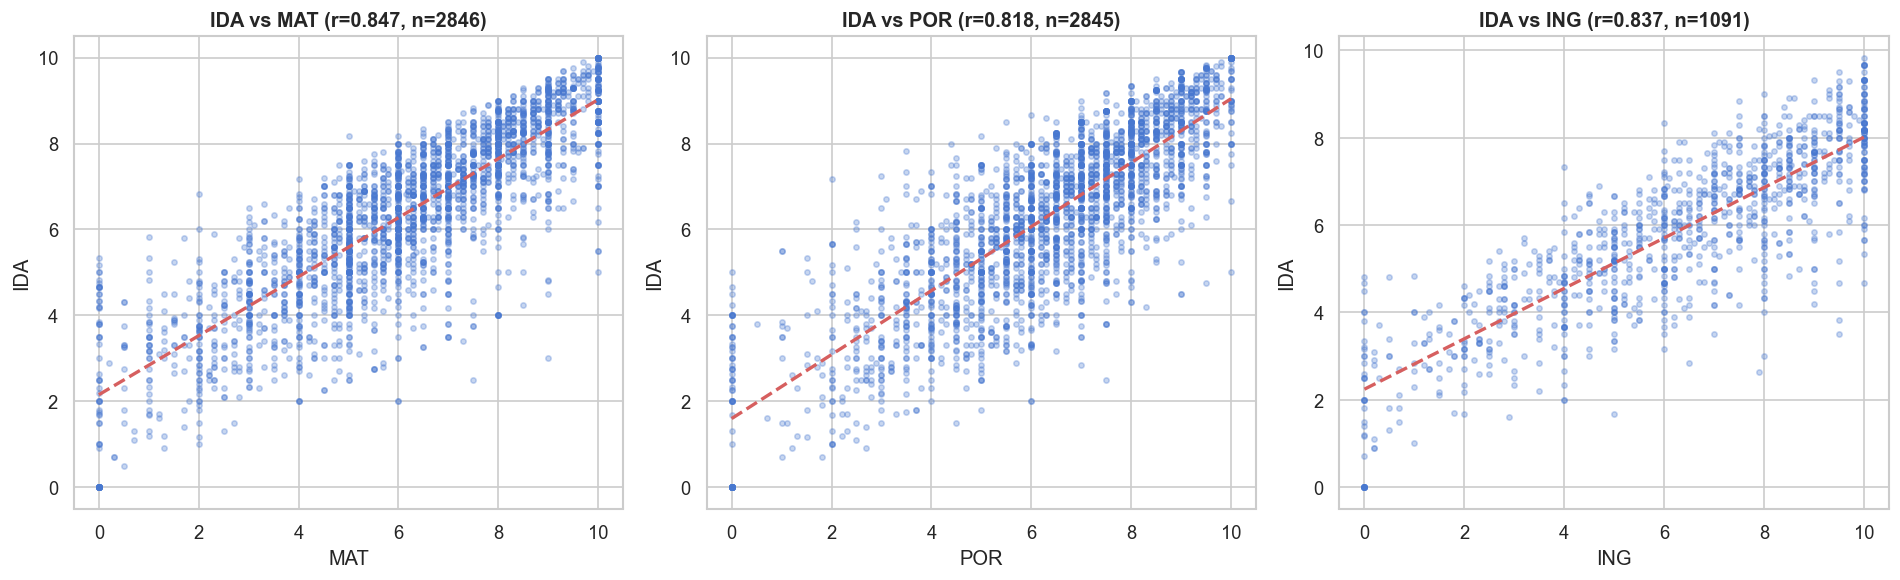

In [35]:
# Correlação entre IDA e notas por disciplina
disciplinas = ['mat', 'por', 'ing']
df_disc = df[['IDA', 'ano'] + disciplinas].dropna(subset=['IDA'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, disc in enumerate(disciplinas):
    dados = df_disc[['IDA', disc]].dropna()
    axes[i].scatter(dados[disc], dados['IDA'], alpha=0.3, s=10)

    # Linha de regressão
    if len(dados) > 10:
        z = np.polyfit(dados[disc], dados['IDA'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(dados[disc].min(), dados[disc].max(), 100)
        axes[i].plot(x_range, p(x_range), 'r--', linewidth=2)

    corr = dados[disc].corr(dados['IDA'])
    axes[i].set_title(f'IDA vs {disc.upper()} (r={corr:.3f}, n={len(dados)})', fontweight='bold')
    axes[i].set_xlabel(disc.upper())
    axes[i].set_ylabel('IDA')

plt.tight_layout()
plt.show()

##### 💡 Insights 

- Todas as matérias mostram um valor de r(correlação de Pearson) acima de 0.8, o que traz isso como uma correlação forte
  - O que faz sentido, já que o IDA é calculado a partir dessas notas hehe

- Número de registros para MAT e POR são iguais, o que faz sentido
- ING é menor, pois inglês não é avaliado em todas as fases

#### Alunos defasados têm desempenho pior?

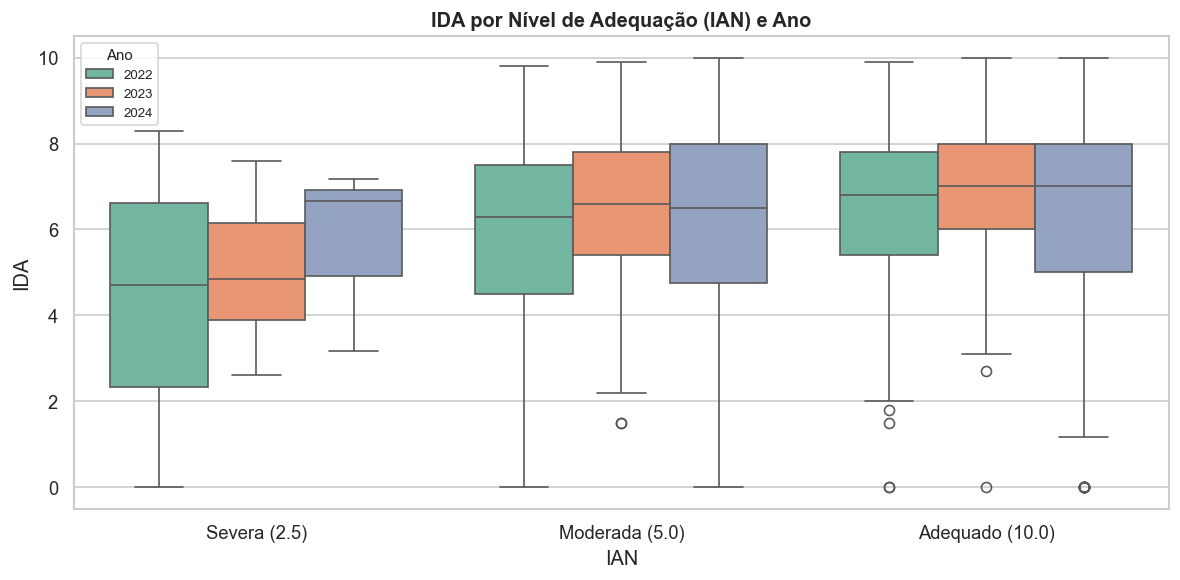

=== IDA médio por IAN e ano ===
                 mean             count          
ano              2022  2023  2024  2022 2023 2024
grupo_ian                                        
Adequado (10.0)  6.47  6.92  6.49   259  388  521
Moderada (5.0)   6.01  6.52  6.22   573  535  531
Severa (2.5)     4.38  4.98  5.67    28   14    3


In [36]:
# Alunos defasados têm desempenho pior?
df_ida_ian = df[df['IDA'].notna() & df['IAN'].notna()].copy()
df_ida_ian['grupo_ian'] = df_ida_ian['IAN'].map({
    2.5: 'Severa (2.5)', 5.0: 'Moderada (5.0)', 10.0: 'Adequado (10.0)'
})

fig, ax = plt.subplots(figsize=(10, 5))
ordem = ['Severa (2.5)', 'Moderada (5.0)', 'Adequado (10.0)']
sns.boxplot(data=df_ida_ian, x='grupo_ian', y='IDA', hue='ano',
            order=ordem, ax=ax, palette='Set2')
ax.set_title('IDA por Nível de Adequação (IAN) e Ano', fontweight='bold')
ax.set_xlabel('IAN')
ax.set_ylabel('IDA')
ax.legend(title='Ano', loc='upper left', fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()

# Tabela resumo
resumo = df_ida_ian.pivot_table(
    index='grupo_ian', columns='ano', values='IDA', aggfunc=['mean', 'count']
).round(2)
print('=== IDA médio por IAN e ano ===')
print(resumo.to_string())

#### 💡 Insights Finais


**O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos??**
- O IDA médio **oscilou** (6.09 → 6.66 → 6.35)
  - Não há tendência clara de melhora ou piora
- A queda de 2023 -> 2024 é generalizada (afeta veteranos e ingressantes igualmente)
  - A queda ocorreu devido a um número meio que enganoso de 2023
  - 13 alunos não completaram o ciclo, tendo IDA nulo. Com apenas 10 alunos, a média ficou em 7.81
  - Em 2024, esses 13 alunos tiveram IDA. Se usarmos a média deles de 2024 para "recalcular" 2023, o valor baixaria de 7.81 -> 5.81, ficando similar aos outros anos (2022: 5.25 | 2024: 5.81)
- A mediana se manteve estável (~6.75)

**Alguns destaques adicionais:**
- **Nível 3 é o pior entre todos**
  - IDA consistentemente mais baixo nos 3 anos (5.14 -> 5.75 -> 5.35)
- Níveis 5 e 6 mostram tendência de melhora

**Disciplinas:**
- MAT, POR e ING têm correlação muito alta e similar com o IDA (r ≈ 0.82–0.85)
- Nenhuma disciplina isolada explica o desempenho — o IDA reflete aprendizagem geral

**Defasagem vs desempenho:**
- Alunos adequados (IAN=10) têm IDA ~0.4 pontos acima dos defasados moderados — diferença existe mas é pequena
- ⚠️ **Insight-chave:** defasagem e desempenho acadêmico são **dimensões parcialmente independentes** — um aluno pode estar defasado mas ter bom IDA, e vice-versa. Isso reforça a importância de usar múltiplos indicadores no modelo de ML, não só o IAN
 

**Para o modelo de ML:**
- ⚠️ Os 4 alunos com IDA=0 e IEG=0 em 2024 são um **sinal claro de risco** — estão no programa mas desengajados
- 💡 Ausência de avaliação em um ano seguida de IDA=0 no ano seguinte pode ser um padrão preditivo de desengajamento


### Exportação da base analítica para o Streamlit


In [37]:
# EXPORTAR BASE ANALITICA DO IDA PARA O STREAMLIT
from pathlib import Path
import sys

# Usa o caminho conhecido do app a partir dos notebooks de AED.
caminho_app = Path('../../app').resolve()
if str(caminho_app) not in sys.path:
    sys.path.append(str(caminho_app))

from analise_exploratoria.analiticos.ida import exportar_base_analitica_ida

# Gera o parquet analitico que a aba IDA do Streamlit passa a consumir.
caminho_saida = exportar_base_analitica_ida(df)
print(f'Base analitica do IDA exportada para: {caminho_saida}')


Base analitica do IDA exportada para: /Users/hgirardi/Documents/Dev/pessoal/Pos_Tech_DTAT/Fase_5/Datathon/data/db/02_gold_analytics/ida_analitico.parquet


In [38]:
# Le o artefato gerado para validar rapidamente a exportacao no proprio notebook.
ida_parquet = pd.read_parquet(caminho_saida)


In [39]:
# Exibe as colunas finais para conferir o contrato usado pela aba do Streamlit.
ida_parquet.columns


Index(['ano', 'RA', 'nome', 'genero', 'idade', 'ano_ingresso', 'instituicao',
       'fase', 'turma', 'nivel', 'fase_ideal', 'defasagem', 'pedra', 'INDE',
       'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'mat', 'por', 'ing',
       'indicado_bolsa', 'atingiu_pv', 'rec_psicologia', 'pedra_20',
       'pedra_21', 'pedra_22', 'pedra_23', 'nivel_label', 'nivel_ordem',
       'grupo_ian', 'primeiro_ano', 'tipo_aluno'],
      dtype='object')